Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.3181 - loss: 1.8645 - val_accuracy: 0.4879 - val_loss: 1.4439
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4770 - loss: 1.4721 - val_accuracy: 0.5411 - val_loss: 1.2940
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5161 - loss: 1.3457 - val_accuracy: 0.5498 - val_loss: 1.2689
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5414 - loss: 1.2732 - val_accuracy: 0.5655 - val_loss: 1.2288
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5698 - loss: 1.2033 - val_accuracy: 0.5853 - val_loss: 1.1624
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5935 - loss: 1.1375 - val_accuracy: 0.6004 - val_loss: 1.1208
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6065 - loss: 1.0925 - val_accuracy: 0.6084 - val_loss: 1.1121
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6219 - loss: 1.0500 - val_accuracy: 0.

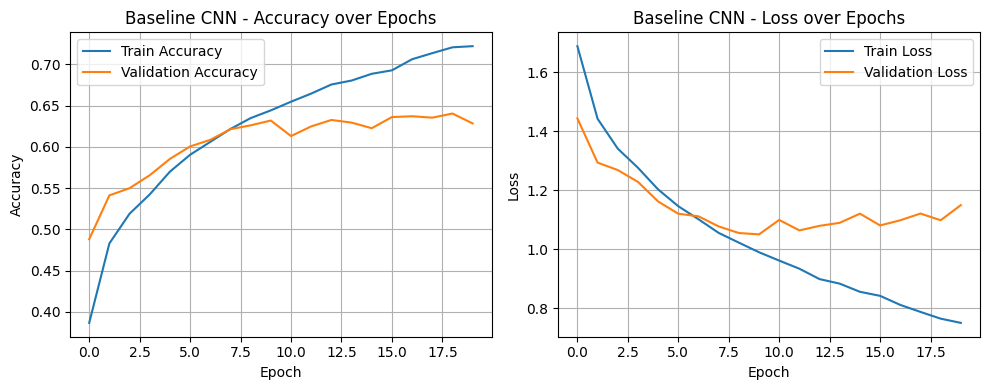

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

📊 Baseline Model Classification Report:
              precision    recall  f1-score   support

    airplane       0.70      0.68      0.69      1000
  automobile       0.75      0.72      0.74      1000
        bird       0.59      0.41      0.48      1000
         cat       0.39      0.51      0.44      1000
        deer       0.56      0.57      0.56      1000
         dog       0.49      0.59      0.53      1000
        frog       0.79      0.65      0.71      1000
       horse       0.68      0.70      0.69      1000
        ship       0.75      0.76      0.75      1000
       truck       0.69      0.71      0.70      1000

    accuracy                           0.63     10000
   macro avg       0.64      0.63      0.63     10000
weighted avg       0.64      0.63      0.63     10000


Macro F1-score: 0.6292


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

# 1. Load CIFAR-10 dataset
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
x_train_full = x_train_full.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# 2. One-hot encode labels
y_train_cat_full = to_categorical(y_train_full, 10)
y_test_cat = to_categorical(y_test, 10)

# 3. Split training set into train + validation
x_train, x_val, y_train_cat, y_val_cat, y_train_raw, y_val_raw = train_test_split(
    x_train_full, y_train_cat_full, y_train_full, test_size=0.2, random_state=42
)

input_shape = x_train.shape[1:]
num_classes = 10

# 4. Define baseline CNN model
def baseline_model():
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Conv2D(32, (5, 5), activation='relu'))
    model.add(MaxPooling2D())
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 5. Train the model
model = baseline_model()
history = model.fit(
    x_train, y_train_cat,
    epochs=20,
    batch_size=64,
    validation_data=(x_val, y_val_cat),
    verbose=1
)

# 6. Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"\n✅ Baseline Model Test Accuracy: {test_acc:.4f}")

# 7. Plot accuracy and loss
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Baseline CNN - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Baseline CNN - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 8. Classification report
y_pred = np.argmax(model.predict(x_test), axis=1)
print("\n📊 Baseline Model Classification Report:")
print(classification_report(y_test, y_pred, target_names=[
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]))

# 9. Macro F1-score
f1 = f1_score(y_test, y_pred, average='macro')
print(f"\nMacro F1-score: {f1:.4f}")


In [ ]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from sklearn.metrics import f1_score, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

# Load and preprocess CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Split validation set
x_val, y_val = x_train[-5000:], y_train_cat[-5000:]
x_train, y_train_cat = x_train[:-5000], y_train_cat[:-5000]

input_shape = x_train.shape[1:]

# Discrete options
filters_list = [16, 32, 64, 128]
dense_list = [64, 128, 256]

# GA+PSO bounds
bounds = {
    "conv_layers": (1, 3),
    "filters_idx": (0, len(filters_list)-1),
    "kernel": (3, 5),
    "dropout": (0.2, 0.5),
    "dense_idx": (0, len(dense_list)-1)
}


# Decode solution to build CNN model
def decode_solution(sol):
    num_conv = int(np.clip(round(sol[0]), *bounds["conv_layers"]))
    filters = filters_list[int(np.clip(round(sol[1]), 0, len(filters_list)-1))]
    kernel = int(np.clip(round(sol[2]), *bounds["kernel"]))
    kernel += 1 if kernel % 2 == 0 else 0  # ensure odd kernel
    dropout = float(np.clip(sol[3], *bounds["dropout"]))
    dense_units = dense_list[int(np.clip(round(sol[4]), 0, len(dense_list)-1))]

    model = Sequential()
    model.add(Input(shape=input_shape))
    for _ in range(num_conv):
        model.add(Conv2D(filters, (kernel, kernel), activation='relu', padding='same'))
        model.add(MaxPooling2D())
    model.add(Flatten())
    model.add(Dropout(dropout))
    model.add(Dense(dense_units, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Fitness evaluation
def evaluate_fitness(sol):
    model = decode_solution(sol)
    model.fit(x_train, y_train_cat, epochs=10, batch_size=64, verbose=0, validation_data=(x_val, y_val))
    y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)
    score = f1_score(y_test, y_pred, average='macro')
    return score, model, y_pred

# GA+PSO parameters
pop_size = 5
generations = 10
dimensions = 5
inertia = 0.7
c1 = 1.5
c2 = 1.5
mutation_rate = 0.2

# Initialize population
population = []
velocities = []
personal_best = []
personal_best_scores = []

for _ in range(pop_size):
    sol = np.array([
        np.random.randint(*bounds["conv_layers"]),
        np.random.randint(*bounds["filters_idx"]),
        np.random.randint(*bounds["kernel"]),
        np.random.uniform(*bounds["dropout"]),
        np.random.randint(*bounds["dense_idx"])
    ])
    population.append(sol)
    velocities.append(np.random.uniform(-1, 1, dimensions))
    personal_best.append(sol.copy())
    score, model, y_pred = evaluate_fitness(sol)
    personal_best_scores.append(score)

# Initialize global best
best_idx = np.argmax(personal_best_scores)
global_best = personal_best[best_idx]
global_best_score = personal_best_scores[best_idx]
global_best_model = decode_solution(global_best)
best_y_pred = np.argmax(global_best_model.predict(x_test, verbose=0), axis=1)

fitness_progress = []

# GA+PSO loop
for gen in range(generations):
    print(f"\nGeneration {gen+1}")
    for i in range(pop_size):
        r1, r2 = np.random.rand(), np.random.rand()
        velocities[i] = (
            inertia * velocities[i] +
            c1 * r1 * (personal_best[i] - population[i]) +
            c2 * r2 * (global_best - population[i])
        )
        new_sol = population[i] + velocities[i]

        #Mutation
        if np.random.rand() < mutation_rate:
            idx = np.random.randint(dimensions)
            key = list(bounds.keys())[idx]
            if "idx" in key:
                new_sol[idx] = np.random.randint(0, bounds[key][1]+1)
            else:
                new_sol[idx] = np.random.uniform(*bounds[key])

        # Clamp all values safely
        new_sol[0] = np.clip(round(new_sol[0]), *bounds["conv_layers"])          # conv layers
        new_sol[1] = np.clip(round(new_sol[1]), 0, len(filters_list) - 1)        # filters index
        new_sol[2] = np.clip(round(new_sol[2]), *bounds["kernel"])               # kernel size
        new_sol[3] = np.clip(new_sol[3], *bounds["dropout"])                     # dropout
        new_sol[4] = np.clip(round(new_sol[4]), 0, len(dense_list) - 1)          # dense index

        #Evaluate fitness
        score, model, y_pred = evaluate_fitness(new_sol)

        #Safely access hyperparameters for print
        filters_idx = int(new_sol[1])
        dense_idx = int(new_sol[4])
        print(f"  Individual {i+1}: Conv={int(new_sol[0])}, Filters={filters_list[filters_idx]}, Kernel={int(new_sol[2])}, Dropout={new_sol[3]:.2f}, Dense={dense_list[dense_idx]} => F1={score:.4f}")

        #Update personal/global bests
        if score > personal_best_scores[i]:
            personal_best[i] = new_sol
            personal_best_scores[i] = score
            if score > global_best_score:
                global_best = new_sol
                global_best_score = score
                global_best_model = model
                best_y_pred = y_pred
                print(f"  New Best Macro F1: {global_best_score:.4f}")

        population[i] = new_sol
    fitness_progress.append(global_best_score)


# Final results
print("\nBest Hyperparameters Found:")
print(f"Conv Layers: {int(global_best[0])}")
print(f"Filters: {filters_list[int(global_best[1])]}")
print(f"Kernel Size: {int(global_best[2])}")
print(f"Dropout: {global_best[3]:.2f}")
print(f"Dense Units: {dense_list[int(global_best[4])]}")
print(f"Macro F1-score: {global_best_score:.4f}")

# Classification report
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
print("\n Classification Report (GA+PSO Optimized Model):")
print(classification_report(y_test, best_y_pred, target_names=class_names))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step

Generation 1
  Individual 1: Conv=3, Filters=128, Kernel=4, Dropout=0.50, Dense=64 => F1=0.7403
    🎉 New Best Macro F1: 0.7403
  Individual 2: Conv=2, Filters=128, Kernel=4, Dropout=0.50, Dense=64 => F1=0.7124
  Individual 3: Conv=3, Filters=128, Kernel=4, Dropout=0.20, Dense=64 => F1=0.7199
  Individual 4: Conv=2, Filters=16, Kernel=3, Dropout=0.50, Dense=64 => F1=0.6593
  Individual 5: Conv=3, Filters=128, Kernel=4, Dropout=0.20, Dense=64 => F1=0.7317

Generation 2
  Individual 1: Conv=3, Filters=128, Kernel=4, Dropout=0.50, Dense=64 => F1=0.7375
  Individual 2: Conv=3, Filters=128, Kernel=4, Dropout=0.50, Dense=64 => F1=0.7407
    🎉 New Best Macro F1: 0.7407
  Individual 3: Conv=3, Filters=128, Kernel=4, Dropout=0.20, Dense=64 => F1=0.7308
  Individual 4: Conv=3, Filters=32, Kernel=3, Dropout=0.50, Dense=64 => F1=0.6722
  Individual 5: Conv=3, Filters=128, Kernel=5, Dropout=0.33, Dense=64 => F1=0.7361

Generation 3
  Individual

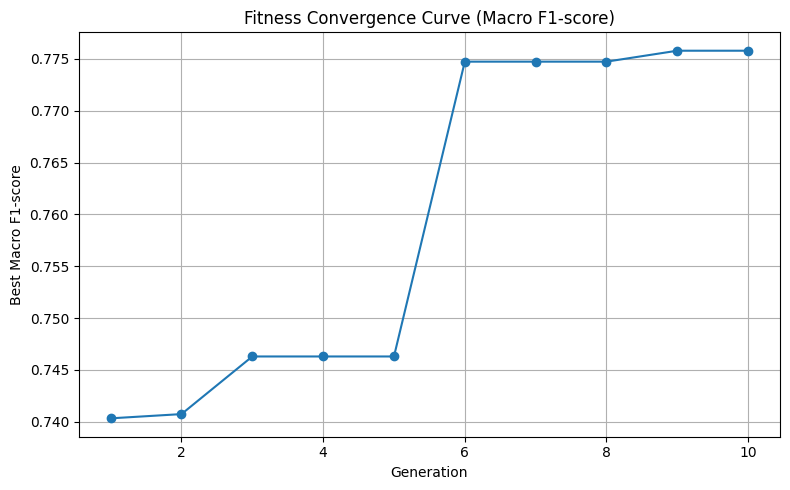

In [ ]:
import matplotlib.pyplot as plt

# Plot fitness convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, generations + 1), fitness_progress, marker='o', linestyle='-')
plt.title('Fitness Convergence Curve (Macro F1-score)')
plt.xlabel('Generation')
plt.ylabel('Best Macro F1-score')
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# Merge training and validation sets
x_full_train = np.concatenate([x_train, x_val])
y_full_train_cat = np.concatenate([y_train_cat, y_val])

# Rebuild the best model with updated decode_solution (with batch norm + RMSprop)
final_model = decode_solution(global_best)

# Callbacks
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    ReduceLROnPlateau(patience=3, factor=0.5)
]

# Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_full_train)

# Train with augmentation
history = final_model.fit(
    datagen.flow(x_full_train, y_full_train_cat, batch_size=64),
    epochs=20,  # or increase if needed
    callbacks=callbacks,
    validation_data=(x_test, y_test_cat),
    verbose=1
)


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


782/782 ━━━━━━━━━━━━━━━━━━━━ 31s 35ms/step - accuracy: 0.3224 - loss: 1.8269 - val_accuracy: 0.5331 - val_loss: 1.2646 - learning_rate: 0.0010
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5143 - loss: 1.3322 - val_accuracy: 0.6180 - val_loss: 1.0611 - learning_rate: 0.0010
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.5762 - loss: 1.1901 - val_accuracy: 0.6488 - val_loss: 0.9675 - learning_rate: 0.0010
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6113 - loss: 1.0905 - val_accuracy: 0.6894 - val_loss: 0.8991 - learning_rate: 0.0010
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.6366 - loss: 1.0176 - val_accuracy: 0.7019 - val_loss: 0.8548 - learning_rate: 0.0010
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6575 - loss: 0.9639 - val_accuracy: 0.7033 - val_loss: 0.8440 - learning_rate: 0.0010
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.6639 - loss: 0.9479

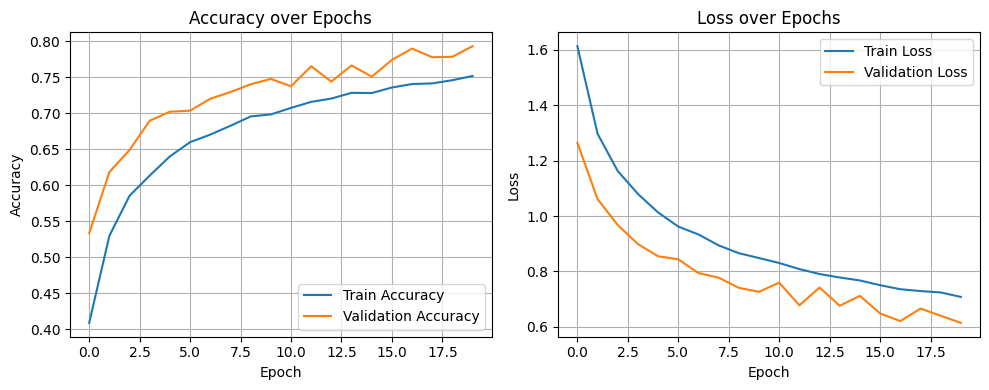

In [ ]:
# Step 6: Plot accuracy and loss
plt.figure(figsize=(10, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Predict test labels
final_y_pred = np.argmax(final_model.predict(x_test, verbose=0), axis=1)

# Calculate Macro F1-score
from sklearn.metrics import f1_score, classification_report

final_f1 = f1_score(y_test, final_y_pred, average='macro')
print(f"\nFinal Retrained Macro F1-score on Test Set: {final_f1:.4f}")

# Print classification report
print("\nFinal Classification Report (After Retraining):")
print(classification_report(y_test, final_y_pred, target_names=class_names))



Final Retrained Macro F1-score on Test Set: 0.7886

Final Classification Report (After Retraining):
              precision    recall  f1-score   support

    airplane       0.77      0.85      0.81      1000
  automobile       0.86      0.94      0.90      1000
        bird       0.81      0.64      0.72      1000
         cat       0.69      0.58      0.63      1000
        deer       0.79      0.78      0.78      1000
         dog       0.81      0.61      0.70      1000
        frog       0.74      0.90      0.81      1000
       horse       0.77      0.88      0.82      1000
        ship       0.90      0.84      0.87      1000
       truck       0.80      0.90      0.85      1000

    accuracy                           0.79     10000
   macro avg       0.79      0.79      0.79     10000
weighted avg       0.79      0.79      0.79     10000



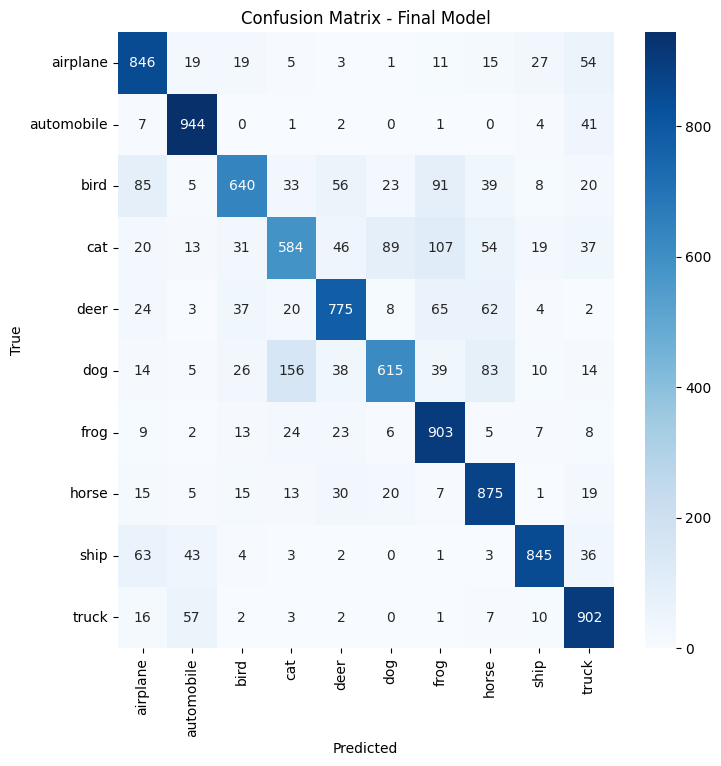

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_y_pred)
plt.figure(figsize=(8, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Final Model")
plt.show()


<ipython-input-19-991797211f85>:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = class_names[int(y_test[i])]


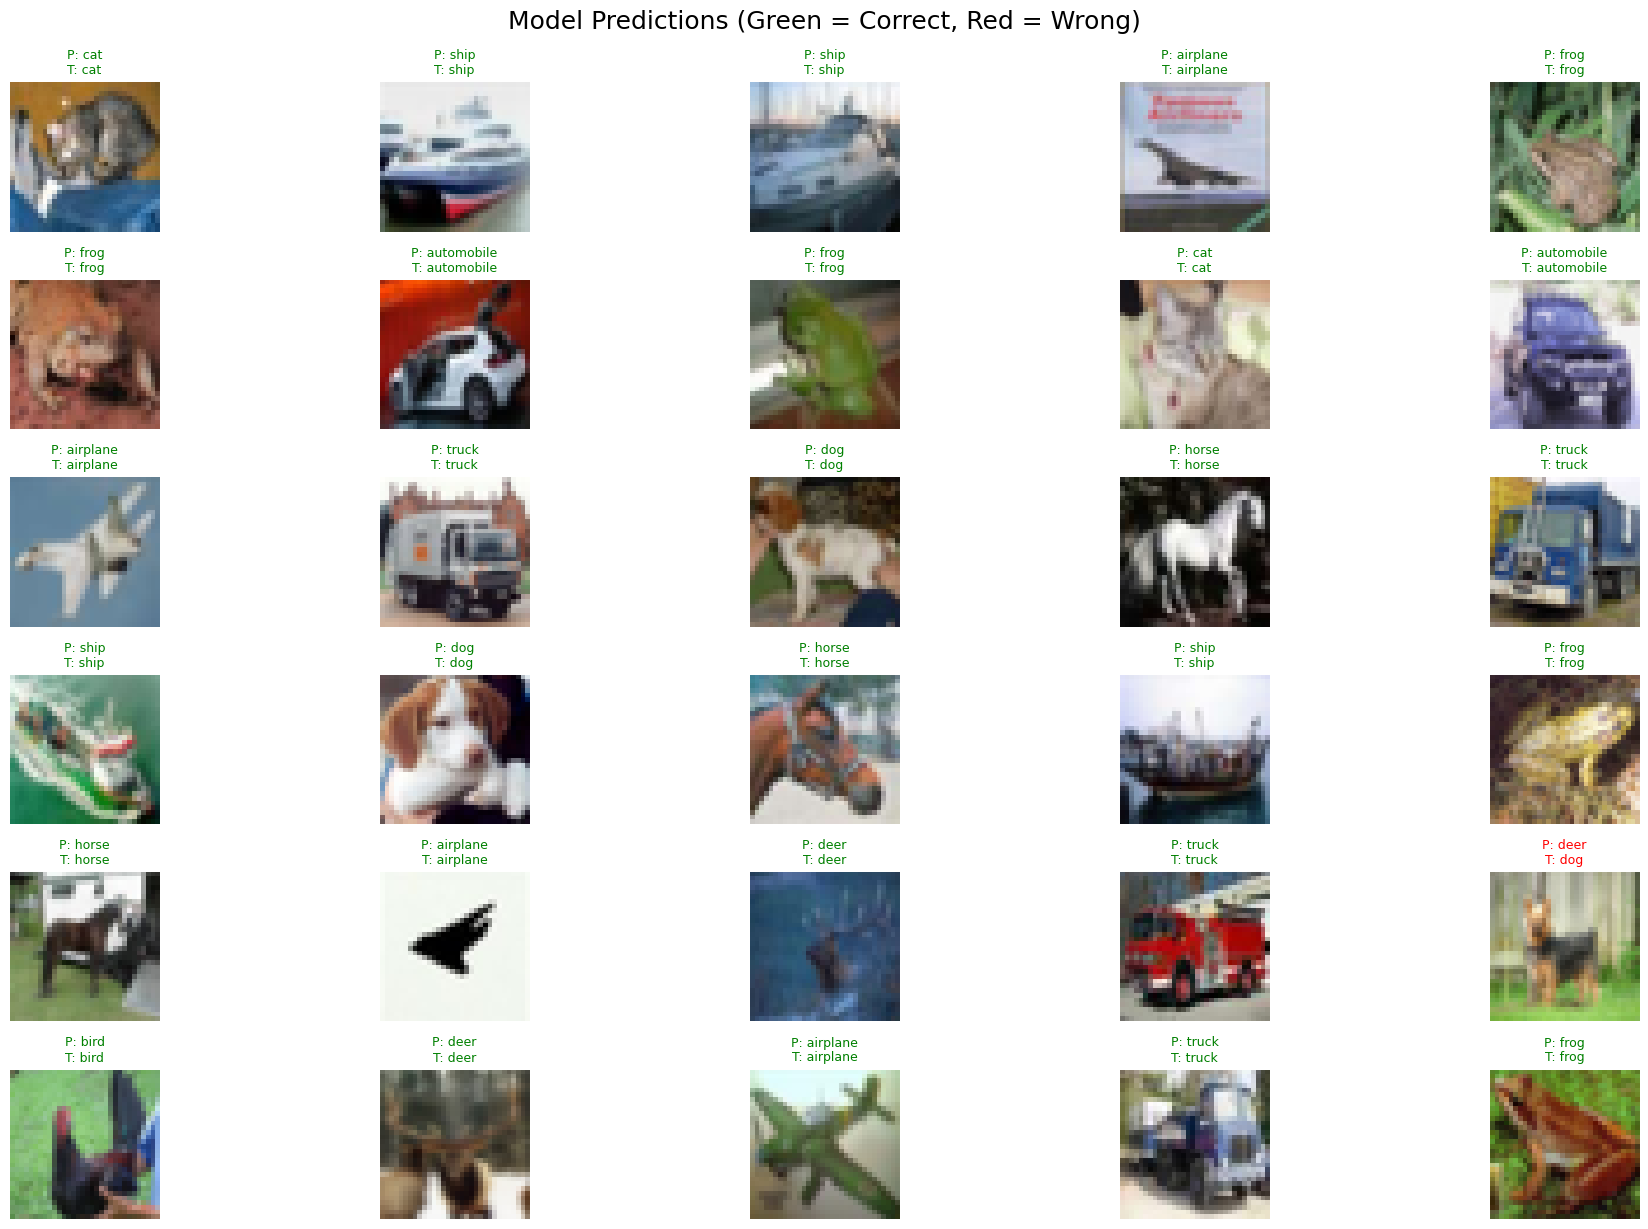

In [ ]:
import matplotlib.pyplot as plt

# Predict test labels
final_y_pred = np.argmax(final_model.predict(x_test, verbose=0), axis=1)

# Number of images to show
num_images = 30
rows, cols = 6, 5

plt.figure(figsize=(20, 12))
for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(x_test[i])
    true_label = class_names[int(y_test[i])]
    predicted_label = class_names[int(final_y_pred[i])]
    color = 'green' if true_label == predicted_label else 'red'
    plt.title(f"P: {predicted_label}\nT: {true_label}", color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.suptitle("Model Predictions (Green = Correct, Red = Wrong)", fontsize=18, y=1.02)
plt.show()
